# CIS 635 Final Project

### Import Neccesary Python Packages

In [129]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


### Census Data Collection and Cleaning

In [130]:
# ---------- 1) Download Census ACS 5-year county data (2023) ----------
# To pull socioeconomic variables from US Census API for county-level analysis
poverty_url = "https://api.census.gov/data/2023/acs/acs5/subject?get=NAME,S1701_C03_001E&for=county:*" # Poverty status in the past 12 months below poverty level
income_url  = "https://api.census.gov/data/2023/acs/acs5/subject?get=NAME,S1901_C01_012E&for=county:*" # Median household income in the past 12 months (in 2023 inflation-adjusted dollars)
edu_url     = "https://api.census.gov/data/2023/acs/acs5/subject?get=NAME,S1501_C02_015E&for=county:*" # Educational attainment for the population 25 years and over: Bachelor's degree or higher

poverty = pd.read_json(poverty_url) 
income  = pd.read_json(income_url)
edu     = pd.read_json(edu_url)

In [131]:
# # Inspect raw Census API output: Census API returns the first row as column labels.
#   We verify the structure before cleaning.
print("Raw poverty head:")
print(poverty.head())

Raw poverty head:
                         0               1      2       3
0                     NAME  S1701_C03_001E  state  county
1  Autauga County, Alabama            10.7     01     001
2  Baldwin County, Alabama            10.5     01     003
3  Barbour County, Alabama            21.9     01     005
4     Bibb County, Alabama            20.5     01     007


In [132]:
# ---------- 2) Fix headers ----------
# Convert the first row into column headers so we can work with clean column names.
poverty.columns = poverty.iloc[0] # Set the first row as column headers
poverty = poverty[1:] # Remove the first row which is now the header
print(poverty.head(5)) # Verify the first few rows to confirm headers are set correctly

#do the same for income and edu
income.columns = income.iloc[0]
income = income[1:]

edu.columns = edu.iloc[0]
edu = edu[1:]

0                     NAME S1701_C03_001E state county
1  Autauga County, Alabama           10.7    01    001
2  Baldwin County, Alabama           10.5    01    003
3  Barbour County, Alabama           21.9    01    005
4     Bibb County, Alabama           20.5    01    007
5   Blount County, Alabama           14.1    01    009


In [133]:
# ---------- 3) Create county FIPS ----------
#   County FIPS = state (2 digits) + county (3 digits).
#   This will be the merge key for county-level fusion.
for df in [poverty, income, edu]:
    df["FIPS"] = df["state"] + df["county"]

print(poverty.head(5)) # Check the new FIPS column
print(income.head(5))
print(edu.head(5))

0                     NAME S1701_C03_001E state county   FIPS
1  Autauga County, Alabama           10.7    01    001  01001
2  Baldwin County, Alabama           10.5    01    003  01003
3  Barbour County, Alabama           21.9    01    005  01005
4     Bibb County, Alabama           20.5    01    007  01007
5   Blount County, Alabama           14.1    01    009  01009
0                     NAME S1901_C01_012E state county   FIPS
1  Autauga County, Alabama          69841    01    001  01001
2  Baldwin County, Alabama          75019    01    003  01003
3  Barbour County, Alabama          44290    01    005  01005
4     Bibb County, Alabama          51215    01    007  01007
5   Blount County, Alabama          61096    01    009  01009
0                     NAME S1501_C02_015E state county   FIPS
1  Autauga County, Alabama           28.3    01    001  01001
2  Baldwin County, Alabama           32.8    01    003  01003
3  Barbour County, Alabama           11.5    01    005  01005
4     Bi

In [134]:
# ---------- 4) Rename variables ----------
# Replace Census cryptic variable codes with meaningful names for readability and analysis.
poverty = poverty.rename(columns={"S1701_C03_001E": "poverty_rate"})
income  = income.rename(columns={"S1901_C01_012E": "median_income"})
edu     = edu.rename(columns={"S1501_C02_015E": "bachelor_plus_rate"})
print(poverty.head(5)) # Check renamed columns
print(income.head(5))
print(edu.head(5))

0                     NAME poverty_rate state county   FIPS
1  Autauga County, Alabama         10.7    01    001  01001
2  Baldwin County, Alabama         10.5    01    003  01003
3  Barbour County, Alabama         21.9    01    005  01005
4     Bibb County, Alabama         20.5    01    007  01007
5   Blount County, Alabama         14.1    01    009  01009
0                     NAME median_income state county   FIPS
1  Autauga County, Alabama         69841    01    001  01001
2  Baldwin County, Alabama         75019    01    003  01003
3  Barbour County, Alabama         44290    01    005  01005
4     Bibb County, Alabama         51215    01    007  01007
5   Blount County, Alabama         61096    01    009  01009
0                     NAME bachelor_plus_rate state county   FIPS
1  Autauga County, Alabama               28.3    01    001  01001
2  Baldwin County, Alabama               32.8    01    003  01003
3  Barbour County, Alabama               11.5    01    005  01005
4     Bibb

In [135]:
# ---------- 5) Merge Census variables into one dataset ----------
# Combine poverty, income, and education variables into a single county-level dataframe.
census_df = poverty[["FIPS", "NAME", "poverty_rate"]].merge(
    income[["FIPS", "median_income"]], on="FIPS").merge(
        edu[["FIPS", "bachelor_plus_rate"]], on="FIPS")
print(census_df.head(5))

0   FIPS                     NAME poverty_rate median_income  \
0  01001  Autauga County, Alabama         10.7         69841   
1  01003  Baldwin County, Alabama         10.5         75019   
2  01005  Barbour County, Alabama         21.9         44290   
3  01007     Bibb County, Alabama         20.5         51215   
4  01009   Blount County, Alabama         14.1         61096   

0 bachelor_plus_rate  
0               28.3  
1               32.8  
2               11.5  
3               11.5  
4               15.6  


In [136]:
# ---------- 6) Convert to numeric ----------
# ensure variables are usable for statistical analysis
# check data types
print(census_df.dtypes)

census_df["poverty_rate"] = pd.to_numeric(census_df["poverty_rate"], errors="coerce") # Convert poverty_rate to numeric, coercing errors to NaN
census_df["median_income"] = pd.to_numeric(census_df["median_income"], errors="coerce")
census_df["bachelor_plus_rate"] = pd.to_numeric(census_df["bachelor_plus_rate"], errors="coerce")
print(census_df.dtypes) # Check that the columns are now numeric

0
FIPS                  object
NAME                  object
poverty_rate          object
median_income         object
bachelor_plus_rate    object
dtype: object
0
FIPS                   object
NAME                   object
poverty_rate          float64
median_income           int64
bachelor_plus_rate    float64
dtype: object


In [137]:
# ---------- 7) Validate Census dataset ----------
# Confirm dataset shape and check missing values.
print("\nCensus dataset shape:", census_df.shape)
print(census_df.head())
print("\nMissing values check:")
print(census_df.isna().sum())


Census dataset shape: (3222, 5)
0   FIPS                     NAME  poverty_rate  median_income  \
0  01001  Autauga County, Alabama          10.7          69841   
1  01003  Baldwin County, Alabama          10.5          75019   
2  01005  Barbour County, Alabama          21.9          44290   
3  01007     Bibb County, Alabama          20.5          51215   
4  01009   Blount County, Alabama          14.1          61096   

0  bachelor_plus_rate  
0                28.3  
1                32.8  
2                11.5  
3                11.5  
4                15.6  

Missing values check:
0
FIPS                  0
NAME                  0
poverty_rate          0
median_income         0
bachelor_plus_rate    0
dtype: int64


In [138]:
# ---------- 8) Load NCES 2022–2023 district-level datasets ----------
# We need district-level outcomes such as dropout and graduation counts.
# NCES CCD provides district (LEA) datasets.
base = os.path.join("..", "Data", "NCES_2022-2023")

lea_path = os.path.join(base, "ccd_lea_029_2223_w_1a_083023.csv")
dropout_path = os.path.join(base, "CCD_LEA_032_2223_L_1a_PUB_050824.CSV")
grad_path = os.path.join(base, "CCD_LEA_040_2223_L_1a_PUB_050824.CSV")

lea_df = pd.read_csv(lea_path, low_memory=False) # Read the LEA file, setting low_memory=False to avoid dtype warnings
dropout_df = pd.read_csv(dropout_path, low_memory=False) # Read the dropout file, setting low_memory=False to avoid dtype warnings
grad_df = pd.read_csv(grad_path, low_memory=False) # Read the graduate file, setting low_memory=False to avoid dtype warnings


In [139]:
# Validate NCES dataset sizes 
# Check whether dataset sizes match expectation.
# LEA Universe file should be ~ 10k-20k rows (districts).
# Dropout and grad files may be larger due to subgroup breakdowns.
print("\nLEA dataset shape:", lea_df.shape)
print("Dropout dataset shape:", dropout_df.shape)
print("Graduate dataset shape:", grad_df.shape)


LEA dataset shape: (19714, 58)
Dropout dataset shape: (206074, 15)
Graduate dataset shape: (344828, 15)


In [140]:
# ---------- 9) Inspect column names----------
# Confirm that LEAID exists in all datasets as the district identifier.
print("LEA columns:\n", lea_df.columns.tolist())
print("Dropout columns:\n", dropout_df.columns.tolist())
print("Graduate columns:\n", grad_df.columns.tolist())

LEA columns:
 ['SCHOOL_YEAR', 'FIPST', 'STATENAME', 'ST', 'LEA_NAME', 'STATE_AGENCY_NO', 'UNION', 'ST_LEAID', 'LEAID', 'MSTREET1', 'MSTREET2', 'MSTREET3', 'MCITY', 'MSTATE', 'MZIP', 'MZIP4', 'LSTREET1', 'LSTREET2', 'LSTREET3', 'LCITY', 'LSTATE', 'LZIP', 'LZIP4', 'PHONE', 'WEBSITE', 'SY_STATUS', 'SY_STATUS_TEXT', 'UPDATED_STATUS', 'UPDATED_STATUS_TEXT', 'EFFECTIVE_DATE', 'LEA_TYPE', 'LEA_TYPE_TEXT', 'OUT_OF_STATE_FLAG', 'CHARTER_LEA', 'CHARTER_LEA_TEXT', 'NOGRADES', 'G_PK_OFFERED', 'G_KG_OFFERED', 'G_1_OFFERED', 'G_2_OFFERED', 'G_3_OFFERED', 'G_4_OFFERED', 'G_5_OFFERED', 'G_6_OFFERED', 'G_7_OFFERED', 'G_8_OFFERED', 'G_9_OFFERED', 'G_10_OFFERED', 'G_11_OFFERED', 'G_12_OFFERED', 'G_13_OFFERED', 'G_UG_OFFERED', 'G_AE_OFFERED', 'GSLO', 'GSHI', 'LEVEL', 'IGOFFERED', 'OPERATIONAL_SCHOOLS']
Dropout columns:
 ['SCHOOL_YEAR', 'FIPST', 'STATENAME', 'ST', 'LEA_NAME', 'STATE_AGENCY_NO', 'UNION', 'ST_LEAID', 'LEAID', 'GRADE', 'RACE_ETHNICITY', 'SEX', 'STUDENT_COUNT', 'TOTAL_INDICATOR', 'DMS_FLAG']
G

In [141]:
# ---------- 10): Confirm common merge keys ----------
#   Identify shared columns and confirm LEAID exists as a unique district identifier.
common_cols = set(lea_df.columns).intersection(set(dropout_df.columns)).intersection(set(grad_df.columns))
print("\nCommon columns in all 3 datasets:", common_cols)


Common columns in all 3 datasets: {'LEA_NAME', 'UNION', 'LEAID', 'ST', 'ST_LEAID', 'FIPST', 'STATENAME', 'STATE_AGENCY_NO', 'SCHOOL_YEAR'}


In [142]:
# ---------- 11):Attempt a naive merge (for diagnostic purposes) ----------

naive_merge = lea_df.merge(dropout_df, on="LEAID", how="left")
naive_merge = naive_merge.merge(grad_df, on="LEAID", how="left")

print("\nNaive merged shape (should NOT be this large):", naive_merge.shape)


Naive merged shape (should NOT be this large): (5156255, 86)


In [143]:
# ---------- 11A) Merge datasets (This step turns out explosion problem) ----------
# This step is used to demonstrate the join explosion problem when mergin datasets and will not be used in the final pipeline.

key = "LEAID" if "LEAID" in lea_df.columns else None # Check if LEAID is in the columns, otherwise set key to None
if key is None:
    raise ValueError("LEAID not found. Need to inspect column names.") # If LEAID is not found, raise an error to inspect column names

# Merge dropout + grad into LEA base
nces_df = lea_df.merge(dropout_df, on=key, how="left", suffixes=("", "_drop")) # Merge dropout data into LEA data, using left join to keep all LEAs, and adding suffixes to distinguish columns
nces_df = nces_df.merge(grad_df, on=key, how="left", suffixes=("", "_grad"))

print("\nMerged NCES shape:", nces_df.shape)
print(nces_df[[key]].head())


Merged NCES shape: (5156255, 86)
    LEAID
0  100002
1  100002
2  100002
3  100002
4  100002


In [144]:
# ---------- 12) : Verify subgroup breakdowns ----------
#   Confirm dropout and grad datasets contain multiple demographic categories per LEAID.
print("\nDropout TOTAL_INDICATOR distribution:")
print(dropout_df["TOTAL_INDICATOR"].value_counts().head(10))

print("\nGraduate TOTAL_INDICATOR distribution:")
print(grad_df["TOTAL_INDICATOR"].value_counts().head(10))

print("\nDropout breakdown examples:")
print(dropout_df[["GRADE", "RACE_ETHNICITY", "SEX"]].drop_duplicates().head(10))

print("\nGraduate breakdown examples:")
print(grad_df[["CREDENTIAL", "RACE_ETHNICITY", "SEX"]].drop_duplicates().head(10))


Dropout TOTAL_INDICATOR distribution:
TOTAL_INDICATOR
Category Set A - By Race/Ethnicity; Sex; Grade    192136
Education Unit Total                               13938
Name: count, dtype: int64

Graduate TOTAL_INDICATOR distribution:
TOTAL_INDICATOR
Category Set A - By Race/Ethnicity; Sex; Credential    309050
Subtotal 1 - By Credential                              22075
Education Unit Total                                    13703
Name: count, dtype: int64

Dropout breakdown examples:


         GRADE                             RACE_ETHNICITY     SEX
0  Grades 9-12           American Indian or Alaska Native  Female
1  Grades 9-12           American Indian or Alaska Native    Male
2  Grades 9-12                                      Asian  Female
3  Grades 9-12                                      Asian    Male
4  Grades 9-12                  Black or African American  Female
5  Grades 9-12                  Black or African American    Male
6  Grades 9-12                            Hispanic/Latino  Female
7  Grades 9-12                            Hispanic/Latino    Male
8  Grades 9-12  Native Hawaiian or Other Pacific Islander  Female
9  Grades 9-12  Native Hawaiian or Other Pacific Islander    Male

Graduate breakdown examples:
                     CREDENTIAL                             RACE_ETHNICITY  \
0             No Category Codes                          No Category Codes   
1  Other high school credential           American Indian or Alaska Native   
2  Other h

In [145]:
# Conclusion:
#   The dropout and grad datasets are NOT one-row-per-district.
#   They contain subgroup-level rows (race, sex, grade, credential).
#   Therefore, we must aggregate them before merging with lea_df.

In [146]:
# ---------- 13）: Extract district total dropout counts ----------
#   "Education Unit Total" indicates the district-level total (all subgroups combined).
#   This avoids double counting and provides a clean district-level measure.

dropout_total = dropout_df[
    dropout_df["TOTAL_INDICATOR"] == "Education Unit Total"
].copy()

print("\nDropout total rows shape:", dropout_total.shape)


Dropout total rows shape: (13938, 15)


In [147]:
# Aggregate dropout count per district (LEAID)
#   Even within total rows, some LEAIDs may appear multiple times (rare), so we sum as a safe method.
dropout_agg = dropout_total.groupby("LEAID")["STUDENT_COUNT"].sum().reset_index()
dropout_agg = dropout_agg.rename(columns={"STUDENT_COUNT": "dropout_count"})

print("Dropout aggregated shape:", dropout_agg.shape)
print(dropout_agg.head())

Dropout aggregated shape: (13938, 2)
    LEAID  dropout_count
0  100002            0.0
1  100005           32.0
2  100006           15.0
3  100007           30.0
4  100008           31.0


In [148]:
# ---------- 14）: Extract district total graduate counts ----------
#   We also filter for "Education Unit Total" to ensure district-level totals.

grad_total = grad_df[
    grad_df["TOTAL_INDICATOR"] == "Education Unit Total"
].copy()

print("\nGraduate total rows shape:", grad_total.shape)


Graduate total rows shape: (13703, 15)


In [149]:
# Aggregate graduate counts by district and credential type
#   This allows us to keep separate counts for diploma types if available.
grad_agg = grad_total.groupby(["LEAID", "CREDENTIAL"])["STUDENT_COUNT"].sum().reset_index()

print("Graduate aggregated shape:", grad_agg.shape)
print(grad_agg.head())

Graduate aggregated shape: (13703, 3)
    LEAID         CREDENTIAL  STUDENT_COUNT
0  100002  No Category Codes            0.0
1  100005  No Category Codes          376.0
2  100006  No Category Codes          401.0
3  100007  No Category Codes          986.0
4  100008  No Category Codes          993.0


In [150]:
# Pivot to wide format: each credential becomes a column
#   This makes the dataset easier to merge and use in ML models.
grad_pivot = grad_agg.pivot(
    index="LEAID",
    columns="CREDENTIAL",
    values="STUDENT_COUNT"
).reset_index()

print(grad_pivot.head())


CREDENTIAL   LEAID  No Category Codes
0           100002                0.0
1           100005              376.0
2           100006              401.0
3           100007              986.0
4           100008              993.0


In [151]:
# Clean column names for modeling stability
#   Replace spaces with underscores and strip whitespace.
grad_pivot.columns = [str(c).strip().replace(" ", "_") for c in grad_pivot.columns]

print("Graduation pivot shape:", grad_pivot.shape)
print(grad_pivot.head())

Graduation pivot shape: (13703, 2)
    LEAID  No_Category_Codes
0  100002                0.0
1  100005              376.0
2  100006              401.0
3  100007              986.0
4  100008              993.0


In [152]:
# ---------- 15): Merge aggregated dropout + graduation into district LEA table ----------
#   lea_df provides district metadata and identifiers.
#   dropout_agg and grad_pivot provide outcome variables.

nces_clean = lea_df.merge(dropout_agg, on="LEAID", how="left")
nces_clean = nces_clean.merge(grad_pivot, on="LEAID", how="left")

print("\nFinal cleaned NCES dataset shape:", nces_clean.shape)
print(nces_clean[["LEAID", "LEA_NAME", "FIPST", "dropout_count"]].head())


Final cleaned NCES dataset shape: (19714, 60)
    LEAID                LEA_NAME  FIPST  dropout_count
0  100002  Alabama Youth Services      1            0.0
1  100005        Albertville City      1           32.0
2  100006         Marshall County      1           15.0
3  100007             Hoover City      1           30.0
4  100008            Madison City      1           31.0


In [153]:
# ---------- 16) Check whether NCES district dataset contains county identifiers ----------
# Scan column names in lea_df for keywords related to county information to confirm whether NCES LEA universse file already inclues county FIPS codes.

possible_county_cols = [c for c in lea_df.columns if "CON" in c.upper() or "COUNT" in c.upper()]
print("\nPossible county columns in lea_df:", possible_county_cols)


Possible county columns in lea_df: []


In [154]:
# Since no county columns exist, we cannot directly merge NCES with Census at the county level. We must use an external geographic crosswalk dataset such as EDGE.

### EDGE County-Level Fusion


In [155]:
# ---------- 17A) Option A: Load EDGE district geocode dataset (LEAID -> county crosswalk) ----------
# Step 16 confirmed that NCES lea_df does not contain county codes, so we need an external crosswalk mapping district IDs (LEAID) to county FIPS.
# Manually assign the correct column names based on EDGE documentation.

edge_txt_path = os.path.join("..", "Data", "EDGE_GEOCODE_PUBLICLEA_2223.txt")

edge_cols = [
    "LEAID", "NAME", "OPSTFIPS", "STREET", "CITY", "STATE", "ZIP",
    "STFIP", "CNTY", "NMCNTY", "LAT", "LON",
    "CBSA", "NMCBSA", "CBSATYPE", "CSA", "NMCSA",
    "NECTA", "NMNECTA", "CD", "SLDL", "SLDU",
    "SCHOOLYEAR", "LOCALE",
    "PCT_CITY11", "PCT_CITY12", "PCT_CITY13",
    "PCT_SUB21", "PCT_SUB22", "PCT_SUB23",
    "PCT_TOWN31", "PCT_TOWN32", "PCT_TOWN33",
    "PCT_RURAL41", "PCT_RURAL42", "PCT_RURAL43"
]

edge_available = os.path.exists(edge_txt_path)
if edge_available:
    edge_df = pd.read_csv(edge_txt_path, sep="|", header=None, names=edge_cols, low_memory=False)
    print("\nEDGE dataset shape:", edge_df.shape)
    print(edge_df.head())
else:
    edge_df = None
    print(f"EDGE file not found at {edge_txt_path}. Skipping Option A county-level fusion.")



EDGE dataset shape: (19714, 36)
    LEAID                    NAME  OPSTFIPS                       STREET  \
0  100002  Alabama Youth Services         1  1000 Industrial School Road   
1  100005        Albertville City         1          8379 US Highway 431   
2  100006         Marshall County         1       12380 US Highway 431 S   
3  100007             Hoover City         1        2810 Metropolitan Way   
4  100008            Madison City         1             211 Celtic Drive   

           CITY STATE    ZIP  STFIP  CNTY             NMCNTY  ...  PCT_CITY13  \
0      Mt Meigs    AL  36057      1  1101  Montgomery County  ...       -2.00   
1   Albertville    AL  35950      1  1095    Marshall County  ...        0.00   
2  Guntersville    AL  35976      1  1095    Marshall County  ...        0.00   
3        Hoover    AL  35243      1  1073   Jefferson County  ...       91.68   
4       Madison    AL  35758      1  1089     Madison County  ...        0.00   

   PCT_SUB21 PCT_SUB22 

In [156]:
# ---------- 18A) Construct standardized 5-digit county FIPS code from EDGE ----------
# Create a clean county-level merge key (FIPS) that matches the Census dataset format.

# What we do:
#   - Force OPSTFIPS into 2-digit format using zfill(2)
#   - Extract last 3 digits of CNTY to ensure proper county code formatting
#   - Concatenate OPSTFIPS + CNTY3 to form the final 5-digit FIPS

if edge_available:
    edge_df["OPSTFIPS"] = edge_df["OPSTFIPS"].astype(str).str.zfill(2) # Force OPSTFIPS into 2-digit format using zfill(2)
    edge_df["CNTY"] = edge_df["CNTY"].astype(str)
    edge_df["CNTY3"] = edge_df["CNTY"].str[-3:] # Extract last 3 digits of CNTY to ensure proper county code formatting
    edge_df["FIPS"] = edge_df["OPSTFIPS"] + edge_df["CNTY3"] # Concatenate OPSTFIPS + CNTY3 to form the final 5-digit FIPS
    print("\nCheck EDGE FIPS construction:")
    print(edge_df[["LEAID", "OPSTFIPS", "CNTY", "CNTY3", "FIPS"]].head())
else:
    print("Skipping FIPS construction because EDGE data is unavailable.")



Check EDGE FIPS construction:


    LEAID OPSTFIPS  CNTY CNTY3   FIPS
0  100002       01  1101   101  01101
1  100005       01  1095   095  01095
2  100006       01  1095   095  01095
3  100007       01  1073   073  01073
4  100008       01  1089   089  01089


In [157]:
# ---------- 19A) Build a EDGE crosswalk table ----------
# For data fusion, we only need LEAID and FIPS plus a few optional variables for analysis/visualization.
# Extract only key columns needed for fusion and interpretation.

if edge_available:
    edge_crosswalk = edge_df[["LEAID", "FIPS", "NMCNTY", "LOCALE", "LAT", "LON"]].copy()
    print("\nEDGE crosswalk shape:", edge_crosswalk.shape)
    print(edge_crosswalk.head())
else:
    edge_crosswalk = None
    print("Skipping EDGE crosswalk build because EDGE data is unavailable.")



EDGE crosswalk shape: (19714, 6)
    LEAID   FIPS             NMCNTY  LOCALE        LAT        LON
0  100002  01101  Montgomery County      41  32.376397 -86.084642
1  100005  01095    Marshall County      32  34.282186 -86.223627
2  100006  01095    Marshall County      42  34.305770 -86.286958
3  100007  01073   Jefferson County      13  33.407169 -86.766082
4  100008  01089     Madison County      21  34.686721 -86.745741


In [158]:
# ---------- 20A) Merge EDGE crosswalk into NCES district outcomes ----------
# Left join nces_clean with edge_crosswalk on LEAID.

if edge_available:
    nces_with_county = nces_clean.merge(edge_crosswalk, on="LEAID", how="left")
    print("\nNCES with county shape:", nces_with_county.shape)
    print(nces_with_county[["LEAID", "LEA_NAME", "FIPS", "NMCNTY"]].head())
    missing_fips_rate = nces_with_county["FIPS"].isna().mean()
    print("\nMissing county FIPS rate after EDGE merge:", missing_fips_rate)
else:
    nces_with_county = None
    missing_fips_rate = None
    print("Skipping NCES-to-EDGE merge because EDGE data is unavailable.")



NCES with county shape: (19714, 65)
    LEAID                LEA_NAME   FIPS             NMCNTY
0  100002  Alabama Youth Services  01101  Montgomery County
1  100005        Albertville City  01095    Marshall County
2  100006         Marshall County  01095    Marshall County
3  100007             Hoover City  01073   Jefferson County
4  100008            Madison City  01089     Madison County

Missing county FIPS rate after EDGE merge: 0.0


In [159]:
# missing_fips_rate = 0 would mean EDGE successfully mapped all LEAIDs to a county FIPS when the file is available.


In [160]:
# ---------- 21A) Fuse NCES district outcomes with Census county-level socioeconomic data ----------
# Create a final fused dataset by merging nces_with_county with census_df on county FIPS. 

if edge_available:
    final_df = nces_with_county.merge(census_df, on="FIPS", how="left")
    print("\nFinal fused dataset shape:", final_df.shape)
    print(final_df[["LEAID", "LEA_NAME", "FIPS", "poverty_rate", "median_income", "bachelor_plus_rate"]].head())
else:
    final_df = None
    print("Skipping county-level Census fusion because EDGE data is unavailable.")



Final fused dataset shape: (19714, 69)
    LEAID                LEA_NAME   FIPS  poverty_rate  median_income  \
0  100002  Alabama Youth Services  01101          19.3        58153.0   
1  100005        Albertville City  01095          16.3        60946.0   
2  100006         Marshall County  01095          16.3        60946.0   
3  100007             Hoover City  01073          16.3        64589.0   
4  100008            Madison City  01089          10.5        83528.0   

   bachelor_plus_rate  
0                34.3  
1                21.3  
2                21.3  
3                35.9  
4                45.7  


In [161]:
# ---------- 22A) Validate fusion success (missing rate check) ----------
# Verify that Census variables successfully merged into NCES records.

if edge_available:
    missing_rates = final_df[["poverty_rate", "median_income", "bachelor_plus_rate"]].isna().mean()
    print("\nMissing rate after Census merge:")
    print(missing_rates)
else:
    missing_rates = None
    print("Skipping county-level missing-rate check because EDGE data is unavailable.")



Missing rate after Census merge:
poverty_rate          0.009435
median_income         0.009435
bachelor_plus_rate    0.009435
dtype: float64


In [162]:
# Missing rate < 1% would suggest most districts successfully matched county-level Census data when the EDGE crosswalk is available.


In [163]:
# ---------- 23A) Inspect districts that failed to match Census ----------
# Identify which districts did not successfully merge with Census variables.
# Extract rows with missing poverty_rate as an indicator of unmatched Census merge.

if edge_available:
    missing_rows = final_df[final_df["poverty_rate"].isna()]
    print("\nExample missing merged rows:")
    print(missing_rows[["LEAID", "LEA_NAME", "FIPS", "STATENAME", "ST"]].head(20))
else:
    missing_rows = None
    print("Skipping unmatched-district inspection because EDGE data is unavailable.")



Example missing merged rows:
         LEAID                               LEA_NAME   FIPS  \
3945   1100087                                   DYRS  11003   
3980   1200084                    IDEA PUBLIC SCHOOLS  12215   
6901   2200252            Northeast Claiborne Charter  22139   
19530  5900025          Turtle Mountain Middle School  59079   
19531  5900026          Naa Tsis'aan Community School  59037   
19532  5900027       Flandreau Indian Boarding School  59101   
19533  5900028               San Ildefonso Day School  59049   
19534  5900029                        Hopi Day School  59017   
19535  5900030                  Santa Rosa Day School  59019   
19536  5900031            CHOCTAW CENTRAL HIGH SCHOOL  59099   
19537  5900032                  Cottonwood Day School  59001   
19538  5900033  Dzilth-Na-O-Dith-Hle Community School  59045   
19539  5900034                   Sequoyah High School  59021   
19540  5900035                    RED ROCK DAY SCHOOL  59001   
19541  590

In [164]:
# When present, unmatched rows are often Tribal, Day School, or Boarding School districts that may not map neatly to standard county geography.


In [165]:
# ---------- 24A) Create final analysis-ready dataset ----------
# Prepare a clean dataset for modeling and statistical analysis.
# Drop rows missing key Census variables (poverty, income, education).

if edge_available:
    final_df_clean = final_df.dropna(
        subset=["poverty_rate", "median_income", "bachelor_plus_rate"]
    ).copy()
    print("Option A final dataset rows:", final_df_clean.shape[0])
else:
    final_df_clean = None
    print("Option A final dataset rows: skipped because EDGE data is unavailable.")


Option A final dataset rows: 19528


### Option A County-Level Analysis


In [166]:
# ---------- 25A) Compute district-level dropout_rate for Option A ----------
# Use the graduation credential columns from grad_pivot and district dropout counts from nces_clean.

if edge_available:
    option_a_credential_cols = [c for c in grad_pivot.columns if c != "LEAID" and c in final_df_clean.columns]
    print("Option A credential columns found:", option_a_credential_cols)

    final_df_clean[option_a_credential_cols] = final_df_clean[option_a_credential_cols].apply(
        pd.to_numeric, errors="coerce").clip(lower=0).fillna(0)
    final_df_clean["dropout_count"] = pd.to_numeric(
        final_df_clean["dropout_count"], errors="coerce").clip(lower=0).fillna(0)

    final_df_clean["total_grads"] = final_df_clean[option_a_credential_cols].sum(axis=1)
    final_df_clean["dropout_rate"] = (
        final_df_clean["dropout_count"] /
        (final_df_clean["dropout_count"] + final_df_clean["total_grads"])
    ) * 100
    final_df_clean["dropout_rate"] = final_df_clean["dropout_rate"].fillna(0)

    print("\nOption A analysis-ready shape:", final_df_clean.shape)
    print(final_df_clean[["LEAID", "LEA_NAME", "FIPS", "poverty_rate", "median_income", "bachelor_plus_rate", "dropout_rate"]].head())
else:
    print("Skipping Option A dropout-rate computation because EDGE data is unavailable.")


Option A credential columns found: ['No_Category_Codes']

Option A analysis-ready shape: (19528, 71)
    LEAID                LEA_NAME   FIPS  poverty_rate  median_income  \
0  100002  Alabama Youth Services  01101          19.3        58153.0   
1  100005        Albertville City  01095          16.3        60946.0   
2  100006         Marshall County  01095          16.3        60946.0   
3  100007             Hoover City  01073          16.3        64589.0   
4  100008            Madison City  01089          10.5        83528.0   

   bachelor_plus_rate  dropout_rate  
0                34.3      0.000000  
1                21.3      7.843137  
2                21.3      3.605769  
3                35.9      2.952756  
4                45.7      3.027344  


In [167]:
# ---------- 26A) Correlation and regression for Option A ----------
if edge_available:
    print("\nOption A correlation with dropout_rate:")
    print(final_df_clean[["poverty_rate", "median_income", "bachelor_plus_rate", "dropout_rate"]].corr()["dropout_rate"].round(4))

    X_a = final_df_clean[["poverty_rate", "median_income", "bachelor_plus_rate"]].fillna(0)
    y_a = final_df_clean["dropout_rate"].fillna(0)

    model_a = LinearRegression()
    model_a.fit(X_a, y_a)
    y_a_pred = model_a.predict(X_a)

    print("\nOption A R^2 Score:", round(r2_score(y_a, y_a_pred), 4))
    print("Option A coefficients:")
    for name, coef in zip(X_a.columns, model_a.coef_):
        print(f"  {name}: {round(coef, 4)}")
    print("Intercept:", round(model_a.intercept_, 4))
else:
    print("Skipping Option A regression because EDGE data is unavailable.")



Option A correlation with dropout_rate:
poverty_rate          0.0759
median_income         0.0047
bachelor_plus_rate   -0.0128
dropout_rate          1.0000
Name: dropout_rate, dtype: float64



Option A R^2 Score: 0.0063
Option A coefficients:
  poverty_rate: 0.2549
  median_income: 0.0
  bachelor_plus_rate: 0.0319
Intercept: 2.4652


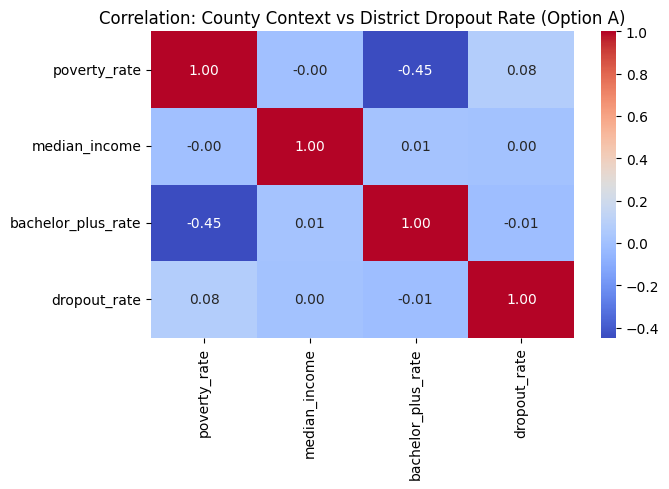

Saved: ..\Images\option_a_correlation_heatmap.png


In [168]:
# ---------- 27A) Option A correlation heatmap ----------
if edge_available:
    option_a_corr_cols = ["poverty_rate", "median_income", "bachelor_plus_rate", "dropout_rate"]
    option_a_corr_matrix = final_df_clean[option_a_corr_cols].corr()

    plt.figure(figsize=(7, 5))
    sns.heatmap(option_a_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation: County Context vs District Dropout Rate (Option A)")
    plt.tight_layout()

    output_path = os.path.join("..", "Images", "option_a_correlation_heatmap.png")
    plt.savefig(output_path, dpi=150)
    plt.show()
    print(f"Saved: {output_path}")
else:
    print("Skipping Option A heatmap because EDGE data is unavailable.")


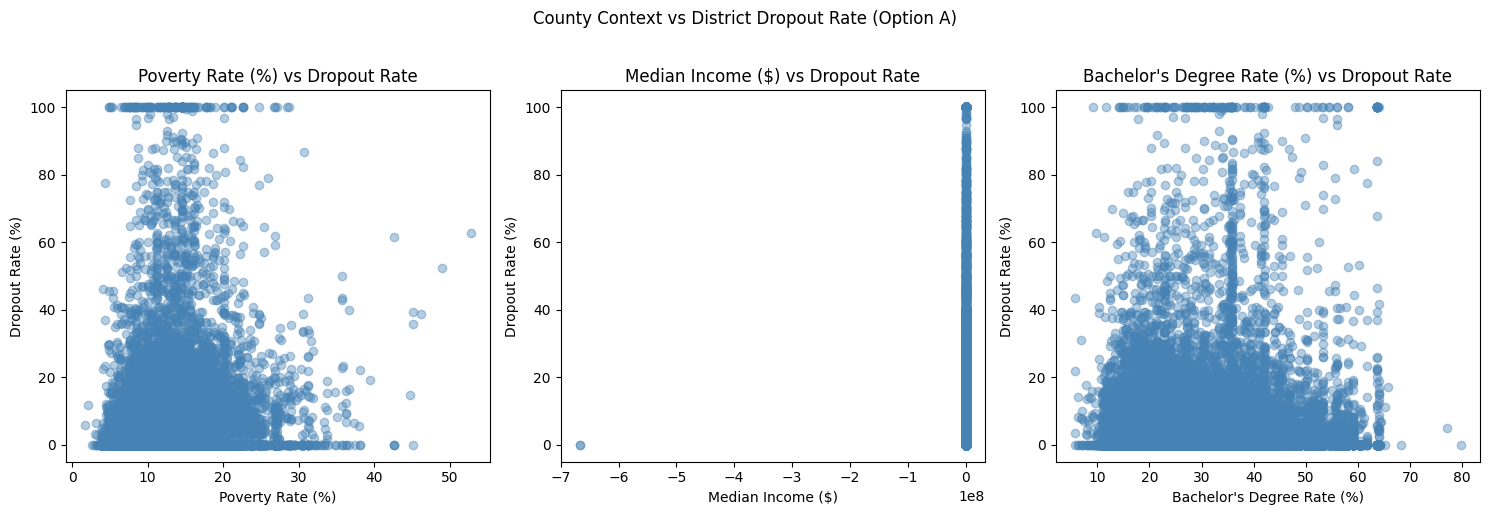

Saved: ..\Images\option_a_scatter_plots.png


In [169]:
# ---------- 28A) Option A scatter plots ----------
if edge_available:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    pairs = [
        ("poverty_rate", "Poverty Rate (%)"),
        ("median_income", "Median Income ($)"),
        ("bachelor_plus_rate", "Bachelor's Degree Rate (%)"),
    ]

    for ax, (col, label) in zip(axes, pairs):
        ax.scatter(final_df_clean[col], final_df_clean["dropout_rate"], alpha=0.4, color="steelblue")
        ax.set_xlabel(label)
        ax.set_ylabel("Dropout Rate (%)")
        ax.set_title(f"{label} vs Dropout Rate")

    plt.suptitle("County Context vs District Dropout Rate (Option A)", y=1.02)
    plt.tight_layout()

    output_path = os.path.join("..", "Images", "option_a_scatter_plots.png")
    plt.savefig(output_path, dpi=150)
    plt.show()
    print(f"Saved: {output_path}")
else:
    print("Skipping Option A scatter plots because EDGE data is unavailable.")


### State-Level Aggregation and Analysis


In [170]:
# ---------- 17B) Option B Baseline: Aggregate Census data from county-level to state-level ----------
# Extract 2-digit state FIPS from the 5-digit county FIPS code
# e.g. "01001" → "01"

census_df["FIPS"] = census_df["FIPS"].astype(str).str.zfill(5)
census_df["state_fips"] = census_df["FIPS"].str[:2]

census_state = census_df.groupby("state_fips").agg(
    poverty_rate       = ("poverty_rate",      "mean"),
    median_income      = ("median_income",     "median"),
    bachelor_plus_rate = ("bachelor_plus_rate","mean")
).reset_index()

print("Census state-level shape:", census_state.shape)
print(census_state.head())

Census state-level shape: (52, 4)
  state_fips  poverty_rate  median_income  bachelor_plus_rate
0         01     18.435821        51551.0           19.522388
1         02     11.943333        78158.0           23.173333
2         04     17.100000        60417.0           23.146667
3         05     18.470667        50221.0           17.606667
4         06     12.851724        80701.5           29.867241


In [171]:
# ---------- 18B) Option B Baseline: Aggregate NCES district-level data to state-level ----------
# nces_clean already has FIPST (2-digit state FIPS as integer)
# Aggregate dropout count and each graduation credential column

nces_clean["state_fips"] = nces_clean["FIPST"].astype(str).str.zfill(2)

# Identify grad credential columns (everything added by the pivot)
grad_cols = [c for c in nces_clean.columns
             if c not in ["LEAID","LEA_NAME","FIPST","state_fips",
                          "STATENAME","ST","dropout_count"]]

agg_dict = {"dropout_count": "sum"}
for col in grad_cols:
    agg_dict[col] = "sum"

nces_state = nces_clean.groupby("state_fips").agg(agg_dict).reset_index()

print("NCES state-level shape:", nces_state.shape)
print(nces_state.head())


NCES state-level shape: (57, 56)
  state_fips  dropout_count  \
0         01         3803.0   
1         02         1783.0   
2         04        15257.0   
3         05         4258.0   
4         06        52825.0   

                                         SCHOOL_YEAR  STATE_AGENCY_NO  UNION  \
0  2022-20232022-20232022-20232022-20232022-20232...              157    0.0   
1  2022-20232022-20232022-20232022-20232022-20232...               54    0.0   
2  2022-20232022-20232022-20232022-20232022-20232...              719    0.0   
3  2022-20232022-20232022-20232022-20232022-20232...              302    0.0   
4  2022-20232022-20232022-20232022-20232022-20232...             2144  570.0   

                                            ST_LEAID  \
0  AL-210AL-101AL-048AL-158AL-169AL-600AL-610AL-1...   
1  AK-31AK-32AK-54AK-55AK-98AK-56AK-04AK-07AK-08A...   
2  AZ-4244AZ-4474AZ-4486AZ-4514AZ-4191AZ-4201AZ-4...   
3  AR-0101000AR-5222000AR-0520000AR-0602000AR-102...   
4  CA-1975309CA-013

In [172]:
#   Option B produces a fused dataset with ~52 observations (states + DC/PR depending on reporting).
#   This is usable for baseline regression, but sample size is limited.

In [173]:
# ---------- 19B) Option B Baseline: Compute dropout_rate at state level ----------
# We must define "total_grads" as the sum of all credential categories from grad_pivot.
# The grad pivot columns from cell 14 are the graduation counts
# Everything else in fused_df from lea_df is administrative (deleted most of fused) - exclude it

# Keep only the columns we actually need
analysis_cols = ["state_fips", "poverty_rate", "median_income", 
                 "bachelor_plus_rate", "dropout_count"]

# Get only credential columns - these come from grad_pivot
# They are whatever columns grad_pivot added beyond LEAID
credential_cols = [c for c in grad_pivot.columns if c != "LEAID"]
print("Credential columns found:", credential_cols)

# Rebuild nces_state from scratch using only what matters
nces_clean["state_fips"] = nces_clean["FIPST"].astype(str).str.zfill(2)

agg_dict2 = {"dropout_count": "sum"}
for col in credential_cols:
    agg_dict2[col] = "sum"

nces_state2 = nces_clean.groupby("state_fips").agg(agg_dict2).reset_index()

# Merge with census state
fused2 = census_state.merge(nces_state2, on="state_fips", how="inner")

# Convert credential columns to numeric, clip negatives
fused2[credential_cols] = fused2[credential_cols].apply(
    pd.to_numeric, errors="coerce").clip(lower=0).fillna(0)

fused2["dropout_count"] = pd.to_numeric(
    fused2["dropout_count"], errors="coerce").clip(lower=0).fillna(0)

# Compute total grads and dropout rate
fused2["total_grads"] = fused2[credential_cols].sum(axis=1)
fused2["dropout_rate"] = (
    fused2["dropout_count"] /
    (fused2["dropout_count"] + fused2["total_grads"])
) * 100
fused2["dropout_rate"] = fused2["dropout_rate"].fillna(0)

print("\nFixed dataset shape:", fused2.shape)
print("\nSample:")
print(fused2[["state_fips","poverty_rate","median_income",
              "bachelor_plus_rate","dropout_rate"]].head(10).round(2))

print("\nDropout rate stats:")
print(fused2["dropout_rate"].describe().round(2))



Credential columns found: ['No_Category_Codes']

Fixed dataset shape: (52, 8)

Sample:
  state_fips  poverty_rate  median_income  bachelor_plus_rate  dropout_rate
0         01         18.44        51551.0               19.52          7.31
1         02         11.94        78158.0               23.17         18.00
2         04         17.10        60417.0               23.15         16.22
3         05         18.47        50221.0               17.61         11.84
4         06         12.85        80701.5               29.87         10.57
5         08         12.07        71230.0               36.05         13.34
6         09          9.79        87564.0               39.87          6.38
7         10         11.00        78162.0               32.83         15.40
8         11         14.50       106287.0               63.60         39.22
9         12         14.66        66154.0               25.24          6.61

Dropout rate stats:
count    52.00
mean     12.44
std       5.92
min       4

### Correlation and Regression Analysis


In [174]:
# ---------- 20B) Rerun correlation and regression on clean data ----------
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print("\nCorrelation with dropout_rate:")
print(fused2[["poverty_rate","median_income",
              "bachelor_plus_rate","dropout_rate"]].corr()["dropout_rate"].round(4))

X2 = fused2[["poverty_rate","median_income","bachelor_plus_rate"]].fillna(0)
y2 = fused2["dropout_rate"].fillna(0)

model2 = LinearRegression()
model2.fit(X2, y2)
y2_pred = model2.predict(X2)

print("\nR² Score:", round(r2_score(y2, y2_pred), 4))
print("Coefficients:")
for name, coef in zip(X2.columns, model2.coef_):
    print(f"  {name}: {round(coef, 4)}")
print("Intercept:", round(model2.intercept_, 4))


Correlation with dropout_rate:
poverty_rate          0.1647
median_income         0.1177
bachelor_plus_rate    0.3240
dropout_rate          1.0000
Name: dropout_rate, dtype: float64

R² Score: 0.1925
Coefficients:
  poverty_rate: 0.3403
  median_income: -0.0
  bachelor_plus_rate: 0.3068
Intercept: -0.5956


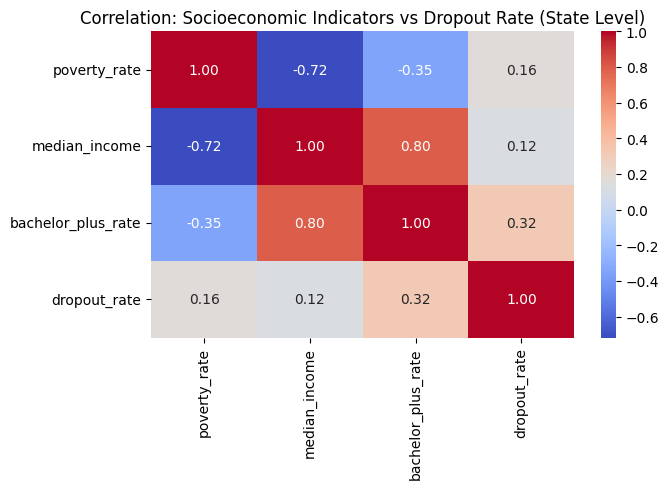

Saved: correlation_heatmap.png


In [175]:
# ---------- 21B) Correlation Heatmap ----------
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = ["poverty_rate", "median_income", "bachelor_plus_rate", "dropout_rate"]
corr_matrix = fused2[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation: Socioeconomic Indicators vs Dropout Rate (State Level)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("Saved: correlation_heatmap.png")

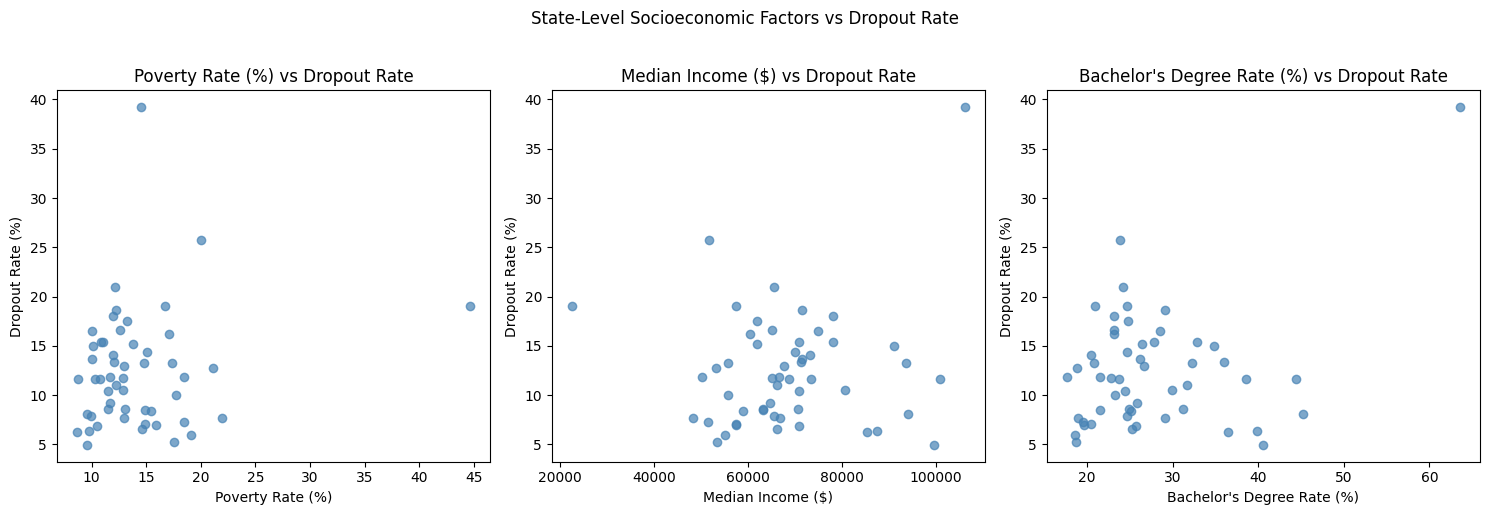

Saved: scatter_plots.png


In [176]:
# ---------- 22B) Scatter plots ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pairs = [
    ("poverty_rate",       "Poverty Rate (%)"),
    ("median_income",      "Median Income ($)"),
    ("bachelor_plus_rate", "Bachelor's Degree Rate (%)"),
]

for ax, (col, label) in zip(axes, pairs):
    ax.scatter(fused2[col], fused2["dropout_rate"], alpha=0.7, color="steelblue")
    ax.set_xlabel(label)
    ax.set_ylabel("Dropout Rate (%)")
    ax.set_title(f"{label} vs Dropout Rate")

plt.suptitle("State-Level Socioeconomic Factors vs Dropout Rate", y=1.02)
plt.tight_layout()
plt.savefig("scatter_plots.png", dpi=150)
plt.show()
print("Saved: scatter_plots.png")